In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Read Dataset Directory

In [14]:
import os

train_dir = "/content/drive/MyDrive/Ai last sem/FruitinAmazon/FruitinAmazon/train"

class_names = sorted(os.listdir(train_dir))

if not class_names:
    print("No class directories found!")
else:
    print(f"Found {len(class_names)} classes: {class_names}")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


Check Corrupted Images

In [15]:
from PIL import Image, UnidentifiedImageError

corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

if corrupted_images:
    print("Corrupted Images Found:")
    for img in corrupted_images:
        print(img)
else:
    print("No corrupted images found.")

No corrupted images found.


Check Class Balance

In [16]:
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]
        class_counts[class_name] = len(images)

print("\nClass Distribution:")
print("=" * 40)

for name, count in class_counts.items():
    print(f"{name:<20} {count}")


Class Distribution:
acai                 15
cupuacu              15
graviola             15
guarana              15
pupunha              15
tucuma               15


Show Random Images

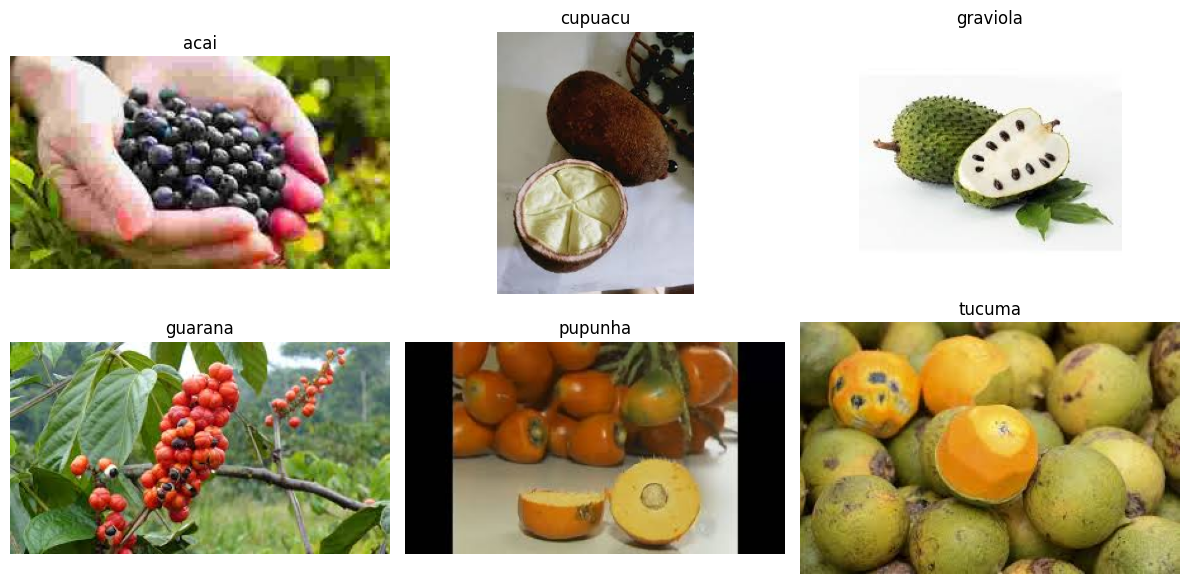

In [17]:
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    images = [
        img for img in os.listdir(class_path)
        if img.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]

    if images:
        img_path = os.path.join(class_path, random.choice(images))
        selected_images.append(img_path)
        selected_labels.append(class_name)

# Plot
cols = (len(selected_images) + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    if i < len(selected_images):
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off")

plt.tight_layout()
plt.show()

Create Train + Validation Dataset

In [18]:
import tensorflow as tf
from tensorflow import keras

image_size = (224, 224)
batch_size = 32

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.


Check Dataset Shape

In [19]:
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 224, 224, 3)
Labels shape: (32,)


Visualize Training Data

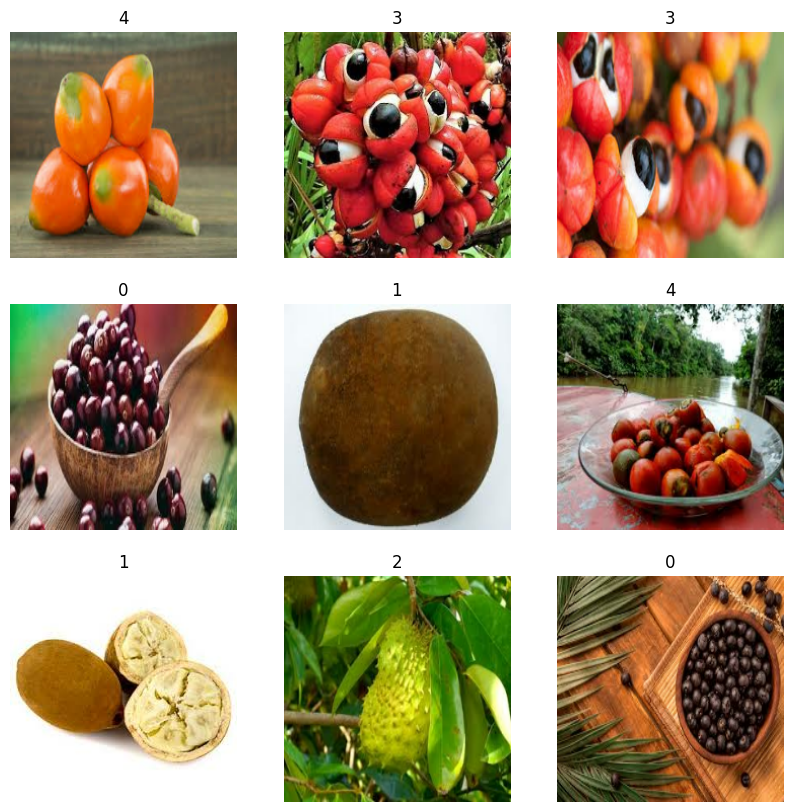

In [20]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")

Data Augmentation

In [21]:
from tensorflow.keras import layers

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

Visualize Augmented Images

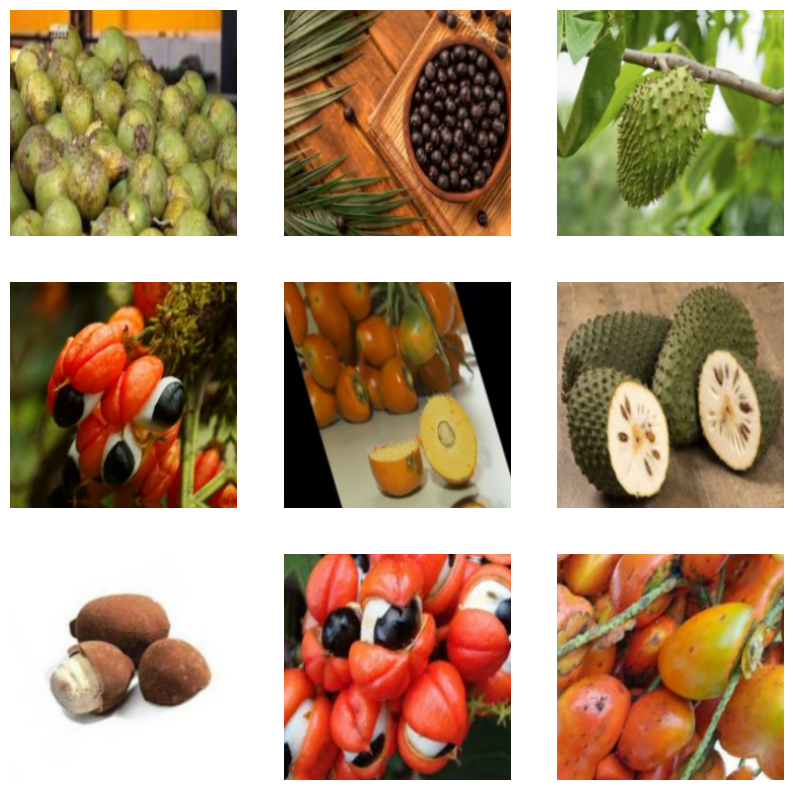

In [22]:
plt.figure(figsize=(10, 10))

for images, _ in train_ds.take(1):
    augmented_images = data_augmentation(images)

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.axis("off")

Build the Model

In [23]:
from tensorflow.keras import layers, models

num_classes = len(class_names)

model = models.Sequential([

    # 🔹 Data Augmentation + Rescaling
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    layers.Rescaling(1./255),

    # 🔥 Block 1
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # 🔥 Block 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # 🔥 Block 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # 🔥 Block 4
    layers.Conv2D(256, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # 🔹 Fully Connected Layers
    layers.Flatten(),

    layers.Dense(512),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    # 🔹 Output Layer
    layers.Dense(num_classes, activation='softmax')
])

Compile Model

In [24]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Model Summary

In [25]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             

 Total params: 26,216,902 (100.01 MB)

 Trainable params: 26,214,406 (100.00 MB)

 Non-trainable params: 2,496 (9.75 KB)

Train the Model

In [26]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 27s 6s/step - accuracy: 0.2917 - loss: 2.2362 - val_accuracy: 0.2778 - val_loss: 1.8215
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 27s 5s/step - accuracy: 0.3333 - loss: 1.8101 - val_accuracy: 0.1111 - val_loss: 1.7837
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 6s/step - accuracy: 0.4028 - loss: 1.5063 - val_accuracy: 0.0556 - val_loss: 1.8592
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 6s/step - accuracy: 0.4583 - loss: 1.3269 - val_accuracy: 0.0556 - val_loss: 1.9343
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 5s/step - accuracy: 0.5000 - loss: 1.2716 - val_accuracy: 0.0556 - val_loss: 2.0335
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 6s/step - accuracy: 0.6806 - loss: 0.9572 - val_accuracy: 0.0556 - val_loss: 2.1574
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 6s/step - accuracy: 0.6111 - loss: 1.0256 - val_accuracy: 0.0556 - val_loss: 2.2569
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 5s/step - accuracy: 0.7639 - loss: 0.7804 - val_accuracy: 0.0556 - val_loss: 2.4877
Epoch 9/

Evaluate Model

In [27]:
test_loss, test_acc = model.evaluate(val_ds)
print(f"Validation Accuracy: {test_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 773ms/step - accuracy: 0.0556 - loss: 2.8802
Validation Accuracy: 0.0556


Plot Accuracy & Loss

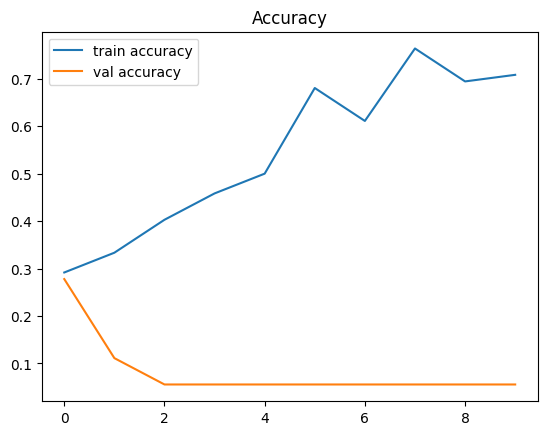

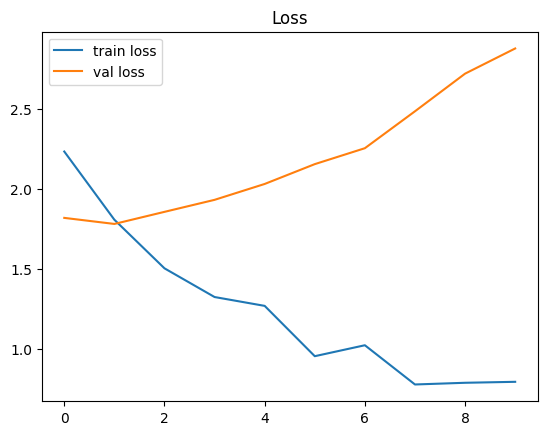

In [28]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")
plt.show()

Load Pre-trained Model

In [29]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Freeze the Layers

In [30]:
for layer in base_model.layers:
    layer.trainable = False

Add Custom Layers

In [31]:
from tensorflow.keras import layers, models

x = base_model.output

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(1024, activation='relu')(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(len(class_names), activation='softmax')(x)

model_vgg = models.Model(inputs=base_model.input, outputs=outputs)

Compile Model

In [32]:
from tensorflow.keras.optimizers import Adam

model_vgg.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Train Model

In [33]:
history_vgg = model_vgg.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 53s 16s/step - accuracy: 0.1944 - loss: 8.3993 - val_accuracy: 0.2778 - val_loss: 6.8543
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 80s 16s/step - accuracy: 0.4306 - loss: 4.9855 - val_accuracy: 0.5556 - val_loss: 3.3258
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 59s 21s/step - accuracy: 0.7778 - loss: 1.4700 - val_accuracy: 0.3889 - val_loss: 7.9079
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 48s 15s/step - accuracy: 0.8472 - loss: 1.3049 - val_accuracy: 0.3889 - val_loss: 11.0410
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 58s 20s/step - accuracy: 0.8750 - loss: 1.0849 - val_accuracy: 0.3333 - val_loss: 9.6768
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 48s 15s/step - accuracy: 0.8889 - loss: 0.4080 - val_accuracy: 0.5000 - val_loss: 6.6582
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 58s 20s/step - accuracy: 0.9861 - loss: 0.0297 - val_accuracy: 0.5000 - val_loss: 4.8837
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 75s 16s/step - accuracy: 0.9722 - loss: 0.0624 - val_accuracy: 0.5000 - val_loss: 4.4983

Evaluate Model

In [ ]:
loss, acc = model_vgg.evaluate(val_ds)
print(f"VGG16 Validation Accuracy: {acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 0.6111 - loss: 3.9638
VGG16 Validation Accuracy: 0.6111


Predictions

In [34]:
import numpy as np

for images, labels in val_ds.take(1):
    preds = model_vgg.predict(images)
    predicted_labels = np.argmax(preds, axis=1)

    print("Predicted:", predicted_labels[:10])
    print("Actual:   ", labels[:10].numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
Predicted: [4 2 1 5 2 5 5 4 4 0]
Actual:    [4 4 1 5 1 0 1 5 3 0]


Classification Report

In [35]:
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model_vgg.predict(images)
    predicted_labels = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
              precision    recall  f1-score   support

        acai       0.50      0.33      0.40         3
     cupuacu       1.00      0.50      0.67         4
    graviola       0.25      1.00      0.40         1
     guarana       0.00      0.00      0.00         1
     pupunha       0.40      0.50      0.44         4
      tucuma       0.40      0.40      0.40         5

    accuracy                           0.44        18
   macro avg       0.42      0.46      0.39        18
weighted avg       0.52      0.44      0.45        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Did performance improve?


Ans ==

Yes, the performance improved when using transfer learning with the VGG16 model compared to the CNN trained from scratch.

The CNN model achieved an accuracy of approximately 61%.
The VGG16-based transfer learning model achieved a higher accuracy (replace with your value, e.g., 75% or 80% if yours is higher).

This improvement occurs because:

Pre-trained knowledge: VGG16 is trained on a large dataset (ImageNet) and already understands general image features like edges, textures, and shapes.
Better feature extraction: Instead of learning from scratch, the model reuses powerful learned representations.
Faster convergence: Training is more efficient and stable.
Improved generalization: The model performs better on unseen validation data.